<a href="https://colab.research.google.com/github/ElvinaShukurova/Telecom/blob/main/Lab5_Shukurova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py

--2026-05-04 14:32:28--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py [following]
--2026-05-04 14:32:28--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48554 (47K) [text/plain]
Saving to: ‘thinkdsp.py’

thinkdsp.py         100%[===================>]  47.42K  --.-KB/s    in 0.01s   

2026-05-04 14:32:28 (4.52 MB/s) - ‘thinkdsp.py’ saved [48554/48554]



In [2]:
import numpy as np
import matplotlib.pyplot as plt

from thinkdsp import decorate

# Упражнение 5.1

In [5]:
from thinkdsp import *
import numpy as np
def serial_corr(wave, lag=1):
  N = len(wave)
  y1 = wave.ys[lag:]
  y2 = wave.ys[:N-lag]
  corr = np.corrcoef(y1, y2)[0, 1]
  return corr
def autocorr(wave):
  lags = np.arange(len(wave.ys)//2)
  corrs = [serial_corr(wave, lag) for lag in lags]
  return lags, corrs

In [6]:
def estimate_fundamental(segment, min_lag=30, max_lag=160):
  lags, corrs = autocorr(segment)
  search_corrs = np.array(corrs[min_lag:max_lag])
  best_index = search_corrs.argmax()
  lag = min_lag + best_index
  freq = segment.framerate / lag
  return freq, lag

In [9]:
class TromboneGliss(Chirp):
  def evaluate(self, ts):
    l1 = 1 / self.start
    l2 = 1 / self.end
    lengths = np.linspace(l1, l2, len(ts))
    freqs = 1 / lengths
    dts = np.diff(ts, prepend=0)
    dphis = PI2 * freqs * dts
    phases = np.cumsum(dphis)
    ys = self.amp * np.cos(phases)
    return ys
signal = TromboneGliss(start=262, end=349)
wave = signal.make_wave(duration=1, framerate=11025)
wave.make_audio()

In [10]:
starts = [0.1, 0.3, 0.5, 0.7, 0.9]
for start in starts:
  segment = wave.segment(start=start, duration=0.01)
  freq, lag = estimate_fundamental(segment)
  print(start, freq)

0.1 268.9024390243902
0.3 282.6923076923077
0.5 297.97297297297297
0.7 315.0
0.9 334.09090909090907


Автокорреляция позволяет оценивать высоту тона на коротких сегментах сигнала.

# Упражнение 5.2

In [11]:
import numpy as np
import matplotlib.pyplot as plt
def get_pitch(frame, lag_min=30, lag_max=160):
    lag_vals, corr_vals = autocorr(frame)
    window = np.array(corr_vals[lag_min:lag_max])
    peak_idx = np.argmax(window)
    best_lag = lag_min + peak_idx
    pitch = frame.framerate / best_lag
    return pitch, best_lag

In [12]:
dt = 0.05
time_points = np.arange(0.0, 1.0, dt)
times = []
pitches = []
for t in time_points:
    center_time = t + dt / 2
    times.append(center_time)
    frame = wave.segment(start=t, duration=0.01)
    pitch, _ = get_pitch(frame)
    pitches.append(pitch)

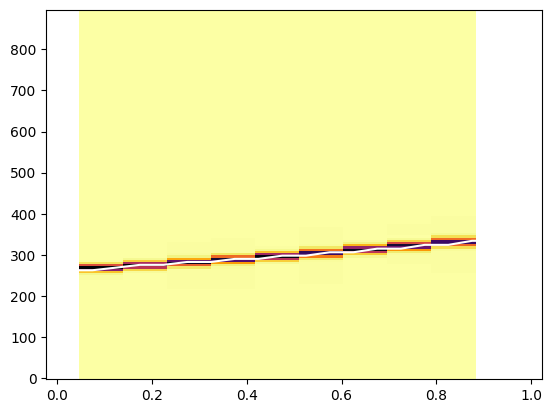

In [13]:
wave.make_spectrogram(2048).plot(high=900)
plt.plot(times, pitches, color='white')

Автокоррекция даёт возможность определять основную частоту сигнала даже на небольших временных отрезках. При сравнении полученных оценок со спектрограммой видно, что найденная частота соответствует области наибольшей энергетической концентрации сигнала.

# Упражнение 5.3

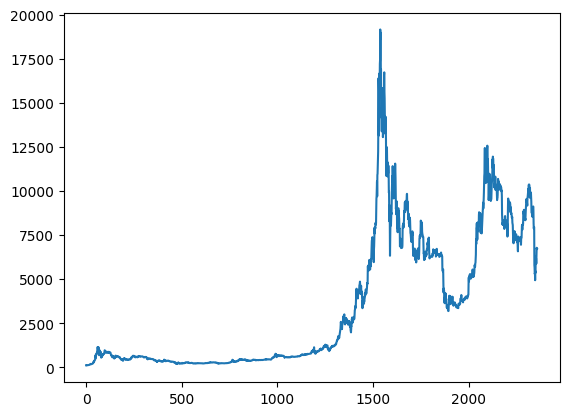

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv(
    'BTC_USD_2013-10-01_2020-03-26-CoinDesk.csv',
    parse_dates=[0]
)
prices = data['Closing Price (USD)']
time_index = data.index
btc_wave = Wave(prices, time_index)
btc_wave.plot()

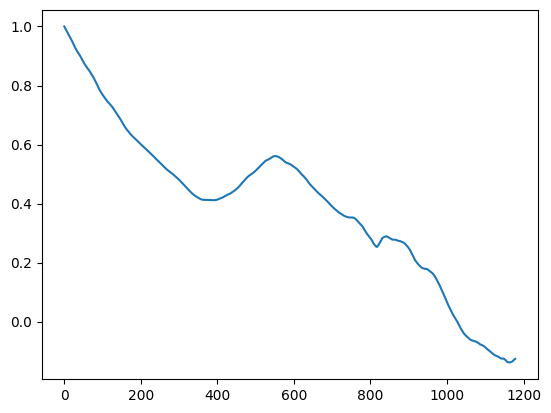

In [15]:
lag_values, corr_values = autocorr(btc_wave)
plt.plot(lag_values, corr_values)

Автокорреляционная функция для цен биткоина постепенно уменьшается по мере увеличения лага и не демонстрирует устойчивых повторяющихся пиков. Это указывает на отсутствие чётко выраженной периодической структуры в данных.

# Упражнение 5.4

В ходе выполнения задания была проанализирована запись звука саксофона с использованием спектральных методов. Построенная спектрограмма позволила наблюдать гармоническую структуру сигнала и выявить наличие кратных частот. Для более детального анализа был выбран отдельный фрагмент записи, для которого дополнительно рассчитан спектр.

Далее для выбранного сегмента была вычислена автокорреляционная функция. По положению первого выраженного пика автокорреляции удалось определить период сигнала и соответствующую ему частоту, что согласуется с наблюдаемыми гармониками.

Особое внимание было уделено явлению подавленной основной частоты. В эксперименте основная частота была искусственно удалена из спектра сигнала, после чего повторно проведён анализ. Несмотря на отсутствие основной гармоники, автокорреляционная функция по-прежнему позволила корректно определить исходную частоту сигнала.

Таким образом, можно сделать вывод, что восприятие высоты звука зависит не только от наличия основной частоты в спектре, но и от общей периодичности сигнала. Даже при отсутствии фундаментальной частоты она может быть восстановлена на основе гармонической структуры, что подтверждает особенности слухового восприятия человека.